# SkinGuide AI: Data Preprocessing and Exploratory Data Analysis (EDA)

## Data Preprocessing

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#### Dataset Information : `beauty_data.csv` , `data.csv`

In [2]:
import pandas as pd

beauty_df = pd.read_csv('E:/SkinGuide/data/raw/beauty_data.csv')
data_df = pd.read_csv('E:/SkinGuide/data/raw/data.csv')

print(f"Initial data rows: {len(data_df)}")
print(f"Initial Beauty Data rows: {len(beauty_df)}")

print("----------beauty_data.csv------------")
beauty_df.info()
print("----------data.csv------------")
data_df.info()

Initial data rows: 19050
Initial Beauty Data rows: 1000
----------beauty_data.csv------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1000 non-null   int64 
 1   brand               1000 non-null   object
 2   name                1000 non-null   object
 3   description         1000 non-null   object
 4   image_name          1000 non-null   object
 5   tags                1000 non-null   object
 6   ingredients_simple  1000 non-null   object
 7   ingredients         1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB
----------data.csv------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19050 entries, 0 to 19049
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19050 non-null  object
 1   nam

#### Missing Values Count

In [3]:
print("----------beauty_data.csv------------")
print(beauty_df.isnull().sum())
print("----------data.csv------------")
print(data_df.isnull().sum())

----------beauty_data.csv------------
id                    0
brand                 0
name                  0
description           0
image_name            0
tags                  0
ingredients_simple    0
ingredients           0
dtype: int64
----------data.csv------------
brand             0
name              0
type             15
country        1832
ingridients     319
afterUse       1524
dtype: int64


### Transform `beauty_data.csv`

##### 1. Drop Unnecessary Columns `id`, `image_name`, `tags`, `ingredients`

In [4]:
beauty_df.drop(['id', 'image_name', 'tags', 'ingredients'], axis=1, inplace=True)
print(beauty_df.columns)

Index(['brand', 'name', 'description', 'ingredients_simple'], dtype='object')


##### 2. Add a `type` column according to `product name`

In [5]:
import re
def infer_type(name):
    name = str(name).lower().strip()
    
    if re.search(r'\b(eye|eyes|ocular|dark circles)\b', name):
        return 'Eye Cream'
        
    if re.search(r'\b(spf|sunscreen|sunblock|uv|sun)\b', name):
        return 'Sunscreen'
        
    if re.search(r'\b(micellar|remover|cleansing balm|cleansing oil|wipe|wipes|makeup|make-up)\b', name):
        return 'Makeup Remover'
        
    if re.search(r'\b(mask|masque|sheet|clay|mud|pack)\b', name):
        return 'Face Mask'
        
    if re.search(r'\b(exfoliat|peel|scrub|bha|aha|pha|polish|resurfacing|microdermabrasion)\b', name):
        return 'Exfoliator'
        
    if re.search(r'\b(cleans|wash|foam|soap)\b', name):
        return 'Face Cleanser'
        
    if re.search(r'\b(essence|ferment|mucin)\b', name):
        return 'Essence'
        
    if re.search(r'\b(serum|ampoule|booster|concentrate|drops|complex)\b', name):
        return 'Serum'
        
    if re.search(r'\b(oil|squalane|rosehip|argan|marula)\b', name):
        return 'Face Oil'
        
    if re.search(r'\b(toner|toning|mist|astringent|pad|pads|water)\b', name):
        return 'Toner'
        
    if re.search(r'\b(cream|moisturiz|lotion|emulsion|gel|balm|fluid|whip|butter|souffle)\b', name):
        return 'General Moisturizer'
    return 'Other'
    
beauty_df['type'] = beauty_df['name'].apply(infer_type)

##### 3. Add `country` column accoring to `brand`

In [6]:
brand_countries = {
    'SkinCeuticals': 'United States', 'Caudalie': 'France', 'Pestle & Mortar': 'Ireland', "Paula's Choice": 'United States', 'Indeed Labs': 'Canada', 'CeraVe': 'United States', 'The Ordinary': 'Canada', 'Drunk Elephant': 'United States', 'Lashfood': 'United States', 'Stridex': 'United States', 'Embryolisse': 'France', 'Hylamide': 'Canada', 'Dermalogica': 'United States', 'Alpha-H': 'Australia', 'The Organic Pharmacy': 'United Kingdom',
    'Indie Lee': 'United States', 'Uncover': 'Netherlands', 'Abitima Clinic': 'Norway', 'Simple': 'United Kingdom', 'La Roche-Posay': 'France', 'Medik8': 'United Kingdom', 'The Body Shop': 'United Kingdom', 'Votary': 'United Kingdom', 'Elizabeth Arden': 'United States', 'Super Facialist': 'United Kingdom', 'Eucerin': 'Germany', 'Glossier': 'United States', 'Clinique': 'United States', 'Pixi': 'United Kingdom', 'Ciate London': 'United Kingdom',
    "Dr. Bronner's": 'United States', 'asap': 'Australia', 'Nip+Fab': 'United Kingdom', 'Derma E': 'United States', 'Omorovicza': 'Hungary', 'Dr. Barbara Stürm': 'Germany', 'Tatcha': 'United States', 'The Little Alchemist': 'Australia', 'Miod': 'Australia', 'Jordan Samuel Skin': 'United States', "Dr. Jackson's": 'United Kingdom', 'Sunday Riley': 'United States', 'Restylane': 'Sweden', 'Bioderma': 'France', 'Nivea': 'Germany',
    'DHC': 'Japan', 'NuFountain': 'United States', 'Neutrogena': 'United States', 'LXMI': 'United States', 'Odacite': 'United States', 'Go-To': 'Australia', 'Stratia': 'United States', 'Holy Snails': 'United States', 'Acne.org': 'United States', 'Julep': 'United States', 'MZ Skin': 'United Kingdom', 'Life Brand': 'Canada', 'Cetaphil': 'Switzerland', 'EltaMD': 'United States', 'COSRX': 'South Korea',
    'Fruit of the Earth': 'United States', 'Polynia': 'Taiwan', 'Etude House': 'South Korea', 'Elemis': 'United Kingdom', 'Boots': 'United Kingdom', 'Superdrug': 'United Kingdom', 'AQ Skin Solutions': 'United States', 'Pyunkang Yul': 'South Korea', 'Klairs': 'South Korea', 'Ultrasun': 'Switzerland', 'Anointment': 'Canada', 'UDDERLY SMOOTH': 'United States', 'NOW Solutions': 'United States', 'Body Shop': 'United Kingdom', 'Manyo Factory': 'South Korea',
    'Timeless': 'United States', 'MV Organic Skincare': 'Australia', 'Superdrug Simply Pure': 'United Kingdom', 'B. by Superdrug': 'United Kingdom', 'Soap and Glory': 'United Kingdom', 'Gosh': 'Denmark', 'Clean & Clear': 'United States', 'M&S Formula': 'United Kingdom', 'Dr Organic': 'United Kingdom', 'Sebamed': 'Germany', 'Superdrug B.': 'United Kingdom', 'CCS': 'Sweden', "It's Skin": 'South Korea', 'Rosette': 'Japan', "Pond's": 'United States',
    'Lixir': 'United Kingdom', 'Vichy': 'France', 'theBalm': 'United States', 'e.l.f.': 'United States', 'NYX': 'United States', 'Stila': 'United States', 'Physiogel': 'Ireland', 'Olay': 'United States', 'Lush': 'United Kingdom', 'bareMinerals': 'United States', 'Living Nature': 'New Zealand', 'Natio': 'Australia', 'Neostrata': 'United States', 'Skin Watchers': 'South Korea', 'Ecooking': 'Denmark',
    'The Chemistry Brand': 'Canada', 'Garnier': 'France', 'Meishoku Ceracolla': 'Japan', 'Maybelline': 'United States', "L'Oreal": 'France', 'NIOD': 'Canada', 'Asarai': 'Australia', 'Intraceuticals': 'Australia', "L'Oreal Paris": 'France', 'Aveeno': 'United States', 'Cliniderm': 'Canada', 'Ducray': 'France', 'Uriage': 'France', 'The PÜRE Collection': 'United Kingdom', 'Isntree': 'South Korea',
    'Kiehl’s': 'United States', 'RAU': 'Germany', 'QV': 'Australia', 'Lily Lolo': 'United Kingdom', 'The Face Shop': 'South Korea', 'ELLE & EVE': 'Canada', 'Verso': 'Sweden', 'Miss Spa': 'United States', 'Vanicream': 'United States', '111SKIN': 'United Kingdom', 'Urban Decay': 'United States', 'SVR': 'France', 'Decubal': 'Denmark', 'Peter Thomas Roth': 'United States', 'Cumlaude': 'Spain',
    'TonyMoly': 'South Korea', 'Fresh': 'United States', 'sCOSMETICS': 'Unknown', 'Advanced Clinicals': 'United States', 'Aesop': 'Australia', 'Matas': 'Denmark', 'Galderma': 'Switzerland', 'Tosowoong': 'South Korea', 'Renee Rouleau': 'United States', 'Pearlessence': 'United States', 'Plaisir by Matas': 'Denmark', 'Solal': 'South Africa', 'Labello': 'Germany', 'Hada Labo': 'Japan', 'Palladio': 'United States',
    'Dr. Jart+': 'South Korea', 'Life-flo': 'United States', 'Erno Laszlo': 'United States', 'LANCER': 'United States', 'silk naturals': 'United States', 'Skinlex': 'United States', 'Cordes': 'Germany', 'bebe': 'Germany', 'Das gesunde Plus': 'Germany', 'Sisley': 'France', 'Chanel': 'France', 'Pacifica': 'United States', 'TeeProSyn': 'Unknown', 'Matas MEDICARE': 'Denmark', 'Biodermal': 'Netherlands',
    'Ling': 'United States', 'Soltan': 'United Kingdom', 'Smashbox': 'United States', 'DNA renewal': 'United States', 'Eternal Secret': 'Mexico', 'Thayers': 'United States', 'Purpose': 'United States', 'Velvet Report': 'United States', 'Alba Botanica': 'United States', 'Free & Clear': 'United States', 'Azelex': 'United States', "Palmer's": 'United States', 'Kose': 'Japan', "Burt's Bees": 'United States', 'Missha': 'South Korea',
    'FÜNFSINNE': 'Austria', 'MINISO': 'China', 'Mixa': 'France', 'Environ': 'South Africa', 'Biologique Recherche': 'France', 'Biore': 'Japan', 'Dermadoctor': 'United States', 'Farsali': 'Canada', 'MooGoo': 'Australia', 'Bio-Oil': 'South Africa', 'Buena Skin Cosmeceuticals': 'United States', 'Top Care': 'United States', 'Corpa Flora': 'Canada', 'HerbiAR': 'United States', 'Boots No7': 'United Kingdom',
    'Atopiclair': 'Italy', 'DMK': 'United States', 'Differin': 'Switzerland', 'Clean And Clear': 'United States', 'Sephora': 'France', 'Tarte': 'United States', 'Nu Skin': 'United States', 'Becca Cosmetics': 'Australia', 'Blossom Jeju': 'South Korea', 'Benefit': 'United States', 'Skinfood': 'South Korea', '10 Degrees Cooler': 'United States', 'Glytone': 'United States', 'Ecoco': 'United States', 'Mellisa B Naturally': 'United States',
    'Vaseline': 'United States', 'Kevyn Aucoin': 'United States', "A'KIN": 'Australia', 'St Ives': 'United States', 'RCMA': 'United States', 'Altruist': 'United Kingdom', 'Oasis Beauty': 'New Zealand', 'Ego QV': 'Australia', 'Bobbi Brown': 'United States', 'Jack Black': 'United States', 'Physicians Formula': 'United States', 'Dermal': 'South Korea', 'RMS Beauty': 'United States', 'DrGL': 'Singapore', 'Lubriderm': 'United States',
    'Dove': 'United States', 'Kiss My Face': 'United States', 'Evidence Skin Care': 'United States', 'Garden of Wisdom': 'United States', 'Caolion': 'South Korea', 'Found': 'United States', 'SheaMoisture': 'United States', 'Natural Instincts': 'Australia', 'Natural Instinct': 'Australia', 'Spring Valley': 'United States', 'iUnik': 'South Korea', 'Sidmool': 'South Korea', 'Huxley': 'South Korea', 'Erborian': 'South Korea', 'skyn ICELAND': 'United States',
    'African Botanics': 'United States', 'Emma Hardie': 'United Kingdom', 'URANG': 'South Korea', 'Olivarrier': 'South Korea', 'OZNaturals': 'United States', 'Bravura London': 'United Kingdom', 'Obagi': 'United States', 'Bulldog': 'United Kingdom', 'Lindsay': 'South Korea', 'The Plant Base': 'South Korea', 'SK-II': 'Japan', 'Yuripibu': 'South Korea', 'LEEGEEHAAM': 'South Korea', 'Yuri Pibu': 'South Korea', 'Vichy Laboratories': 'France',
    'Matas Natur': 'Denmark', 'Mario Badescu': 'United States', 'Balea Med': 'Germany', 'Diadermine': 'France', 'Inecto Naturals': 'United Kingdom', 'Comme Deux': 'Denmark', 'LVLY by Paola Maria': 'Germany', 'RoC': 'France', 'Ecran': 'Spain', '7th Heaven': 'United Kingdom', 'Dermeze': 'Australia', 'Calypso': 'United Kingdom', 'Herbivore': 'United States', 'InstaNatural': 'United States', 'Real Chemistry': 'United States',
    'Skin B5': 'Australia', 'Joa Bath & Body': 'Unknown', 'modest.': 'Hong Kong', 'MD Skinical': 'United States', 'Byphasse': 'Spain', 'Mecca Cosmetica': 'Australia', 'Cyberderm': 'Canada', 'Aritaum': 'South Korea', 'Nuface': 'United States', 'Cow Brand': 'Japan', 'Dasoni': 'South Korea', 'Nature Republic': 'South Korea', 'Sprouts': 'United States', '100% Pure': 'United States', 'Yes To': 'United States',
    'Trilogy': 'New Zealand', 'L´Occitane': 'France', 'Herbivore Botanicals': 'United States', 'Kopari': 'United States', 'Josie Maran': 'United States', 'Angela Caglia': 'United States', 'Payot': 'France', 'This Works': 'United Kingdom', 'Weleda': 'Switzerland', 'Lancôme': 'France', 'innisfree': 'South Korea', 'Nuxe': 'France', 'Antonym': 'United States', 'PHB ETHICAL BEAUTY': 'United Kingdom', 'Skin Laundry': 'United States',
    'Doctor Babor': 'Germany', 'BEAUUGREEN': 'South Korea', 'ECO YOUR SKIN': 'South Korea', 'Lanocreme': 'New Zealand', 'Elizavecca': 'South Korea', 'Jaina Face': 'South Korea', 'Graymelin': 'South Korea', 'Attitude': 'Canada', 'Catrice Cosmetics': 'Germany', 'Essence': 'Germany', 'Cover fx': 'Canada', 'Dermadrate': 'Australia', 'Urtekram': 'Denmark', 'Benefit Cosmetics': 'United States', 'Sol Feliz': 'Unknown',
    'Swanicoco': 'South Korea', 'DR ROEBUCK’S': 'Australia', 'Lily De Mai': 'United Kingdom', 'ICM Pharma': 'Singapore', 'Skin Actives': 'United States', 'omega pharma': 'Belgium', 'RETIRIDES': 'Spain', 'KLAVUU': 'South Korea', 'Purito': 'South Korea', 'EVA NYC': 'United States', 'Free and Clear': 'United States', 'By Wishtrend': 'South Korea', 'The Inkey List': 'United Kingdom', 'Dermedic': 'Poland', 'Pony Effect': 'South Korea',
    'Tailor Skincare': 'New Zealand', 'Skin Aqua': 'Japan', 'Lather': 'United States', 'Wardah': 'Indonesia', 'Joelle Ciocco': 'France', 'KarynG': 'United States', 'Dr. Sam Bunting Skincare': 'United Kingdom', 'Dr Sebagh': 'France', 'Holy land': 'Israel', 'Erbaviva': 'United States', 'The Saem': 'South Korea', 'Rivecowe': 'South Korea', 'Apot.Care': 'France', 'Cal PHARMA': 'United States', 'Marianella': 'United States',
    'Revolution Skincare': 'United Kingdom', 'about-face essentials': 'United States', 'Revolution': 'United Kingdom', 'Unilever': 'United Kingdom', 'Primark - Alex Steinherr': 'Ireland', 'Harborist': 'United Kingdom', 'Balea': 'Germany', 'W3LL People': 'United States', 'Hema': 'Netherlands', 'Emma S.': 'Sweden', 'Avene': 'France', 'SkinMedica': 'United States', 'Lanolips': 'Australia', 'Brandless': 'United States', 'Skin + Pharmacy': 'United States',
    'RITUALS': 'Netherlands', 'Pudderdåserne': 'Denmark', 'Levevis': 'Denmark', 'NudeStix': 'Canada', 'Monu Skin': 'United Kingdom', 'AmorePacific': 'South Korea', 'seaNtree': 'South Korea', 'PCA  Skin': 'United States', 'Farmec Romania': 'Romania', 'A-Derma': 'France', 'Muji': 'Japan', 'Clarks Botanicals': 'United States', 'Apotekets': 'Denmark', 'Cleansing Story': 'South Korea', 'Skin1004': 'South Korea',
    'Biobelle': 'United States', 'Nakeup Face': 'South Korea', 'CV Skin Labs': 'United States', 'TOAS': 'South Korea', 'Orion Pharma': 'Finland', 'Dermosil': 'Finland', 'Fourth Ray': 'United States', 'UFO Youth Junkie Mask': 'Sweden', 'FOREO': 'Sweden', 'Elave': 'Ireland', 'Aquaphor': 'Germany', 'Bielenda': 'Poland', 'Snowberry': 'New Zealand', 'Goldfaden MD': 'United States', 'Sukin': 'Australia',
    'Becca': 'Australia', 'Pai': 'United Kingdom', 'Pharmaceris': 'Poland', 'IOPE': 'South Korea', 'Safi': 'Malaysia', 'Hobe Labs': 'United States', 'Badger': 'United States', 'JAN MARINI': 'United States', "Trader Joe's": 'United States', 'Marc Jacobs': 'United States', 'Biopelle': 'United States', 'Peet Rivko': 'United States', 'Clarins': 'France', 'Shero Science': 'United States', 'Masterplast': 'United Kingdom',
    'Modèle': 'Canada', 'Anthony': 'United States', 'Simple Kind To Skin': 'United Kingdom', 'Aura Cacia': 'United States', 'MALIN + GOETZ': 'United States', 'SunSense': 'Australia', 'Venus': 'United States', 'KIKO Milano': 'Italy', 'Home Health': 'United States', 'Numis med': 'Germany', 'Freederm': 'United Kingdom', '2Sol': 'South Korea', 'The Creme Shop': 'United States', 'CoverGirl': 'United States', 'Hada Labo Tokyo': 'Japan',
    'Derma Revive': 'United Kingdom', 'Larenim': 'United States', 'Skin Inc.': 'Singapore', 'Retrouvé': 'United States', 'Dermavive': 'Australia', 'Neutriderm': 'Australia', 'Urea Labs': 'United States', "A'pieu": 'South Korea', 'Dermastir': 'France', 'Dermaceutic': 'France', 'Sarabecca': 'United States', 'Dr. Lin': 'United States', 'tgin': 'United States', 'Jason': 'United States', 'Bleu & Marine': 'France',
    'Avant': 'United Kingdom', 'Amore Pacific': 'South Korea', 'Tesco': 'United Kingdom', 'Eubos': 'Germany', 'Avon': 'United States', 'Squalan': 'Netherlands', 'Zyderma': 'Canada', 'HydroSkinCare': 'Australia', 'Nilens Jord': 'Denmark', 'NUORI': 'Denmark', 'YOU Skincare': 'United States', 'Pixie': 'United Kingdom', 'Aromatica': 'South Korea', 'Heimish': 'South Korea', 'Acure': 'United States',
    'Curology': 'United States', 'The White Company': 'United Kingdom', 'LANEIGE': 'South Korea', 'Watkins': 'United States', "Nature's Gate": 'United States', 'Abib': 'South Korea', 'TN': 'South Korea', 'No B.S.': 'United States', 'Yves Rocher': 'France', 'Bottega Verde': 'Italy', 'Garnier SkinActive': 'France', 'Avarelle': 'United States', 'Pixi by Petra': 'United Kingdom', 'Bahama Mama': 'United States',
    'Skintegra': 'Croatia', 'Grown Alchemist': 'Australia', 'Kruidvat Natures': 'Netherlands', 'Nacomi': 'Poland', 'SauberKunst': 'Germany', 'Neogen': 'South Korea', 'Lyonsleaf': 'United Kingdom', 'SIMPLYGREENANDNATURAL': 'Unknown', 'TRUE BOTANICALS': 'United States', 'BioBare': 'United States'
}

beauty_df['country'] = beauty_df['brand'].map(brand_countries)

##### 4. Transform `ingredients_simple` and `description` columns

In [7]:
beauty_df['ingredients_simple'] = beauty_df['ingredients_simple'].str.replace('|', ', ', regex=False)
beauty_df.rename(columns={'description' : 'afterUse','ingredients_simple' : 'ingridients'}, inplace=True)

In [8]:
beauty_df.isnull().sum()

brand          0
name           0
afterUse       0
ingridients    0
type           0
country        0
dtype: int64

## Handling missing values of `data.csv`

##### 1. Drop rows where `ingridients` were missing

In [9]:
print("-------Drop missing values by column 'ingridients'--------")
print(f"Shape of dataset (Before) :{data_df.shape}")
data_df.dropna(subset=['ingridients'], inplace=True)
print(f"Shape of dataset (After) :{data_df.shape}")

-------Drop missing values by column 'ingridients'--------
Shape of dataset (Before) :(19050, 6)
Shape of dataset (After) :(18731, 6)


##### 2. fill missing values of column `type` using inference

In [10]:
data_df.loc[data_df['type'].isnull(), 'type'] = data_df.loc[data_df['type'].isnull(), 'name'].apply(infer_type)

##### 3. fill null values of `country` columns according to `brand` name

In [11]:
countries = {
    'Anna Sui': 'United States', 'Esfolio': 'South Korea', 'Elizabeth Arden': 'United States', 'Mielle Organics': 'United States', 'StriVectin': 'United States', 'Yves Saint Laurent': 'France', 'Avon Products': 'United States', 'SCINIC': 'South Korea', 'Farm Stay': 'South Korea', 'Equate': 'United States', 'Formula 10.0.6': 'United States', 'Revolution Beauty': 'United Kingdom', 'MoroccanOil': 'Israel', 'Sally Hansen': 'United States', 'Covergirl': 'United States',
    'Frudia': 'South Korea', 'Vitamins and Sea beauty': 'United States', 'Bath & Body Works': 'United States', 'Beautycounter': 'United States', 'Fenty Beauty': 'United States', 'Tree Hut': 'United States', 'Cantu': 'United States', 'Cremo': 'United States', 'Nu Skin': 'United States', 'Love Beauty and Planet': 'United States', 'J.R. Watkins': 'United States', 'Kylie Skin': 'United States', 'Elizavecca': 'South Korea', 'Jergens Skincare': 'United States', 'Benefit Cosmetics': 'United States',
    'Bobbi Brown': 'United States', 'Jason Skincare': 'United States', 'Tula Skincare': 'United States', 'Guerlain': 'France', 'The Skin House': 'South Korea', 'Maison Margiela': 'France', 'Skincode': 'Switzerland', 'Marc Jacobs Beauty': 'United States', 'Banana Boat': 'United States', 'Nacific': 'South Korea', 'Dr.G': 'South Korea', 'Aromatica': 'South Korea', 'Huxley': 'South Korea', 'Holy Snails': 'United States', 'IMAGE skincare': 'United States',
    'P20': 'Denmark', "Palmer's": 'United States', 'Lab Series for Men': 'United States', 'Vanicream': 'United States', "Harry's": 'United States', 'Gold BJJ': 'United States', 'Oui the People': 'United States', 'Whamisa': 'South Korea', 'Laura Mercier': 'United States', 'Odacité Skincare': 'United States', 'Prima': 'United States', 'Kiwi Botanicals': 'New Zealand', 'Lanoline': 'New Zealand', 'NYX Cosmetics': 'United States', 'Wishful': 'United Arab Emirates',
    'Mary Kay': 'United States', 'heimish': 'South Korea', 'Freck': 'United States', 'BULLDOG': 'United Kingdom', 'so natural': 'South Korea', 'Balance Me': 'United Kingdom', 'Arrow Beauty': 'United States', 'Eminence Organics': 'Hungary', "Old Spice GentleMan's": 'United States', 'BLITHE': 'South Korea', 'BeautyMaker': 'Taiwan', 'The Nue Co': 'United Kingdom', 'MACQUEEN': 'South Korea', 'Lubriderm': 'United States', 'SkinRX Lab': 'South Korea',
    'Asepxia': 'Mexico', 'ILLIYOON': 'South Korea', 'Gisou': 'Netherlands', 'Rare Beauty': 'United States', 'Biologique Recherche': 'France', 'Ardell': 'United States', 'Dewyer': 'United States', 'Son & Park': 'South Korea', 'hims': 'United States', 'Dermedic': 'Poland', 'Wander Beauty': 'United States', 'Every Man Jack': 'United States', 'Herbivore': 'United States', 'ACO': 'Sweden', 'KLAVUU': 'South Korea',
    'W3ll People': 'United States', 'Canmake': 'Japan', 'Alpha-H': 'Australia', 'Blume': 'Canada', 'Marc Anthony': 'Canada', 'CLIO': 'South Korea', 'MAËLYS COSMETICS': 'United States', 'basis': 'Germany', 'Cyberderm': 'Canada', 'Hourglass Cosmetics': 'United States', 'beautyblender': 'United States', 'Milani': 'United States', 'Pur Cosmetics': 'United States', 'All Good': 'United States', 'Black Radiance': 'United States',
    'Geek & Gorgeous': 'Hungary', 'Beauty Without Cruelty': 'United Kingdom', 'Salt by Hendrix': 'Australia', 'rms beauty': 'United States', 'Amlactin': 'United States', 'Earth to Skin': 'United States', 'Andalou Naturals': 'United States', 'Duke Cannon': 'United States', 'Urban Decay': 'United States', 'ThinkSport': 'United States', "Tom's of Maine": 'United States', 'Barr': 'South Korea', 'MooGoo': 'Australia', 'Provence Beauty': 'United States', 'Honeybee Gardens': 'United States',
    'RiRe': 'South Korea', 'Anastasia Beverly Hills': 'United States', 'Stila Cosmetics': 'United States', 'Huda Beauty': 'United Arab Emirates', 'The Plant Base': 'South Korea', 'human+kind': 'Ireland', 'Terre Mère': 'United States', 'Neighbourhood Botanicals': 'United Kingdom', 'Cell:Monde': 'South Korea', 'S’ABLE Labs': 'United Kingdom', 'Epara': 'United Kingdom', 'Garden of Wisdom': 'United States', 'Rosen Skincare': 'United States', 'babo botanicals': 'United States', 'Glo Skin Beauty': 'United States',
    "Schmidt's Naturals": 'United States', '100% Pure': 'United States', 'KVD Vegan Beauty': 'United States', 'Zoeva': 'Germany', 'Chasin Rabbits': 'South Korea', 'Briskin': 'South Korea', 'Lord Jones': 'United States', 'PCA Skin': 'United States', 'Shani Darden': 'United States', 'Open Nature': 'United States', 'Becca': 'Australia', 'Stridex': 'United States', 'Vivant skin care': 'United States', 'Vivo Per Lei': 'United States', '3LAB Skincare': 'United States',
    'Egyptian Magic': 'United States', 'Prosacea': 'United States', 'Yeouth': 'United States', 'Hempz': 'United States', 'Fifth & Root': 'United States', 'Super Facialist': 'United Kingdom', 'Nyakio': 'United States', 'Angel Face Essentials': 'United States', "CJ's Butter": 'United States', 'Base Butter': 'United States', 'Arbonne': 'United States', 'AXIS - Y': 'South Korea', "Dickinson's": 'United States', 'Made From Earth': 'United States', 'iNNBEAUTY PROJECT': 'United States',
    'Jayjun Cosmetic': 'South Korea', 'Moon Juice': 'United States', 'Laura Geller': 'United States', "Humphrey's": 'United States', 'Monday Muse Skincare': 'United Kingdom', 'Olivarrier': 'South Korea', 'Love From Yours': 'Singapore', 'Evian': 'France', 'Bolden': 'United States', 'Neogold': 'United States', 'Skin Beauty Skincare': 'United States', 'M-61': 'United States', 'Tanologist': 'United Kingdom', 'InstaNatural': 'United States', 'Isle of Paradise': 'United Kingdom',
    'Then I Met You': 'United States', 'Dr. Lara Devgan': 'United States', 'Laponie of Scandinavia': 'Finland', 'BeautyStat': 'United States', 'Pretty Skin': 'South Korea', 'KYPRIS': 'United States', 'Golde': 'United States', 'Noble Formula': 'United States', 'Loli Beauty': 'United States', 'FOREO': 'Sweden', 'Ode to Self Skincare': 'United States', 'Elastalift': 'United States', 'lilah b.': 'United States', 'Dr. Different': 'South Korea', 'Oneskin': 'United States',
    "Dr. Roebuck's": 'Australia', 'Lancer Skincare': 'United States', 'INC.redible': 'United Kingdom', 'Skin Republic': 'South Africa', 'Necessaire': 'United States', 'Standard beauty': 'South Africa', 'U beauty': 'United States', 'Skinmade': 'Germany', 'Bio-Oil': 'South Africa', 'PMD Beauty': 'United States', 'Always Be Pure': 'South Korea', 'EVENPRIME': 'United States', 'reviv serums': 'United States', 'Topicals': 'United States', 'SkinKick': 'United States',
    'Hyper Skin': 'United States'
}

data_df.loc[data_df['country'].isnull(), 'country'] = data_df.loc[data_df['country'].isnull(), 'brand'].map(countries)
data_df.isnull().sum()

brand             0
name              0
type              0
country           0
ingridients       0
afterUse       1205
dtype: int64

## Merge two dataframes `data_df` and `beauty_df`

In [12]:
df = pd.concat([data_df, beauty_df], ignore_index=True)

##### Missing values count

In [14]:
df.isnull().sum()
df.to_csv('E:/SkinGuide/data/raw/datasheet.csv', index=False)

## Data Visualization

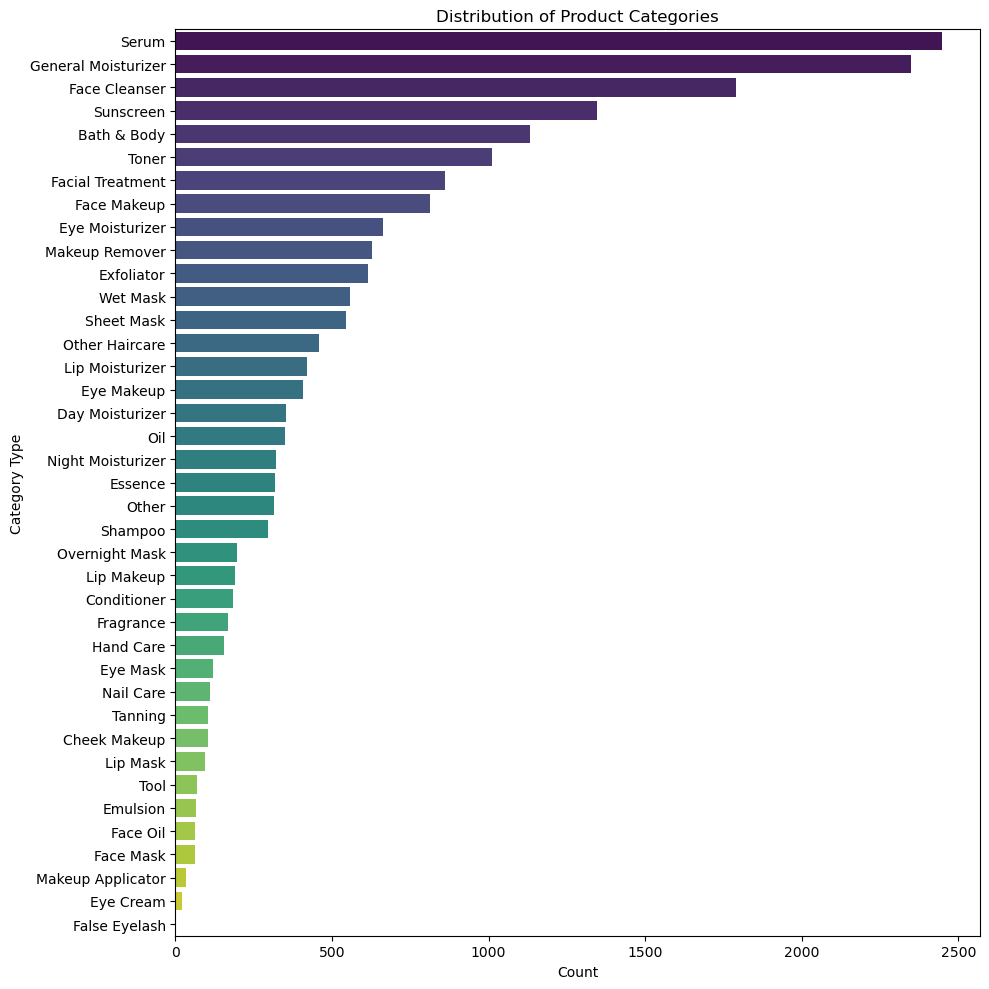

In [22]:
plt.figure(figsize=(10, 10))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index, palette="viridis", legend=False)
plt.title("Distribution of Product Categories")
plt.xlabel("Count")
plt.ylabel("Category Type")
plt.tight_layout()
plt.show()

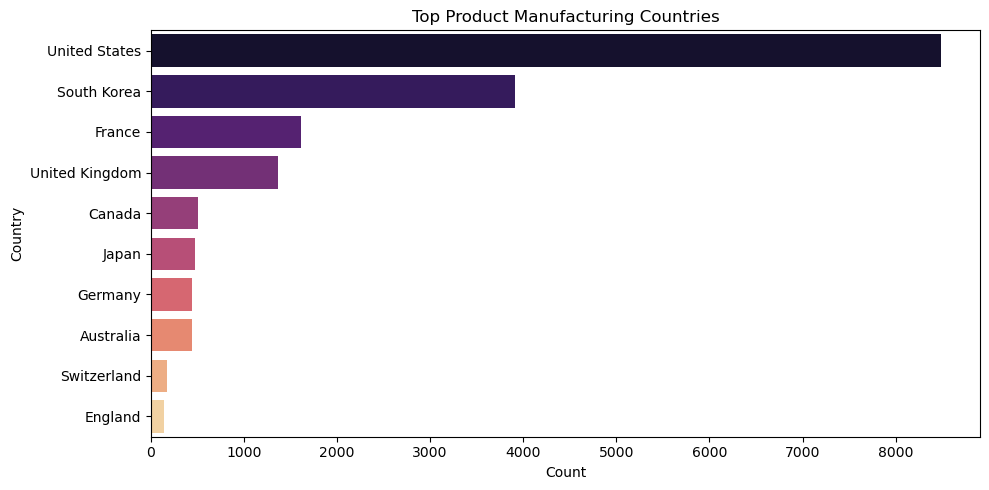

In [16]:
plt.figure(figsize=(10, 5))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette="magma", legend=False)
plt.title("Top Product Manufacturing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

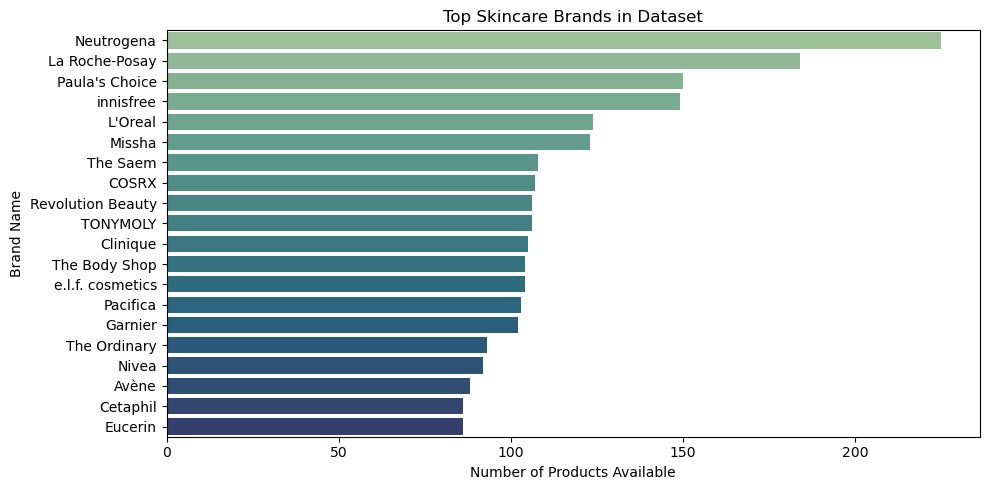

In [17]:
plt.figure(figsize=(10, 5))
brand_counts = df['brand'].value_counts().head(20)
sns.barplot(x=brand_counts.values, y=brand_counts.index, hue=brand_counts.index, palette="crest", legend=False)
plt.title("Top Skincare Brands in Dataset")
plt.xlabel("Number of Products Available")
plt.ylabel("Brand Name")
plt.tight_layout()
plt.show()

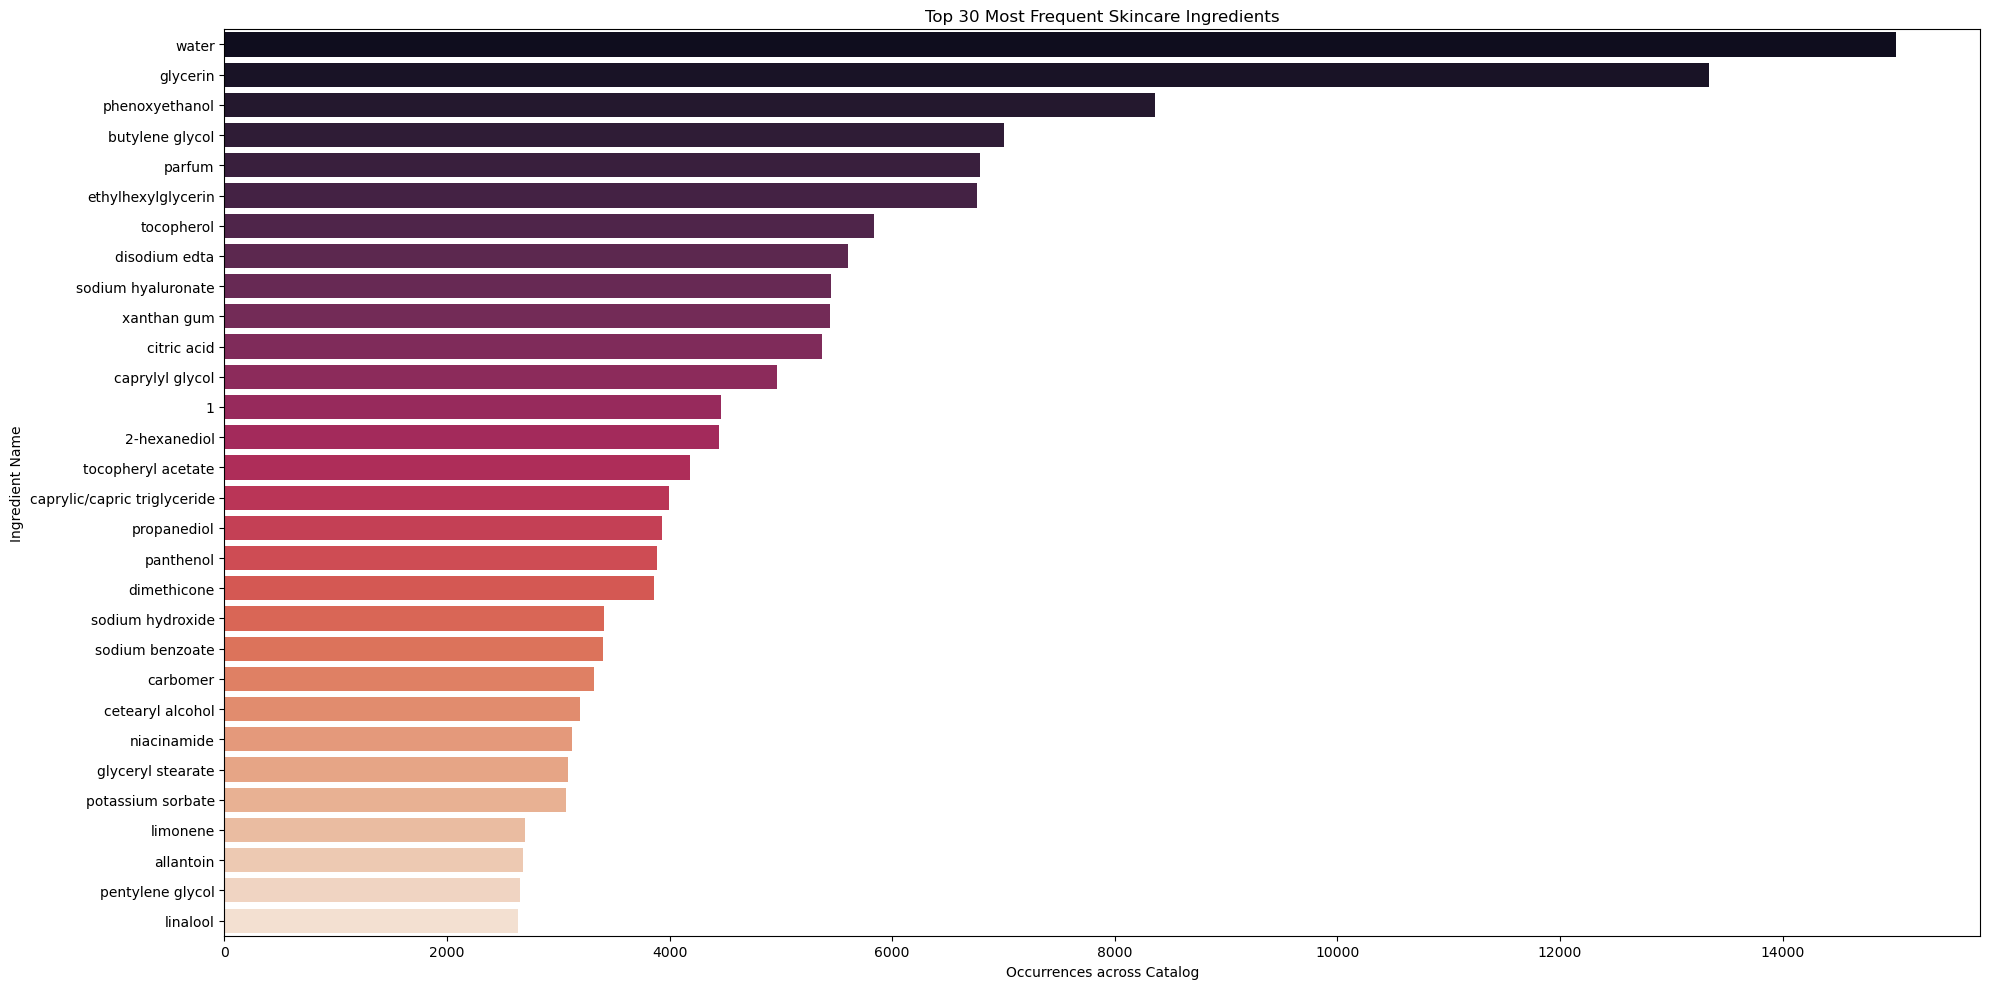

In [18]:
all_ingredients = []

ingredient_col = 'ingridients' if 'ingridients' in df.columns else 'ingredients'

for val in df[ingredient_col].dropna():
    all_ingredients.extend([i.strip().lower() for i in str(val).split(',') if i.strip()])
    
top_ingredients = Counter(all_ingredients).most_common(30)
top_ing_df = pd.DataFrame(top_ingredients, columns=['Ingredient', 'Frequency'])

if not top_ing_df.empty:
    plt.figure(figsize=(20, 10))
    sns.barplot(data=top_ing_df, x='Frequency', y='Ingredient', hue='Ingredient', palette="rocket", legend=False)
    plt.title("Top 30 Most Frequent Skincare Ingredients")
    plt.xlabel("Occurrences across Catalog")
    plt.ylabel("Ingredient Name")
    plt.tight_layout()
    plt.show()

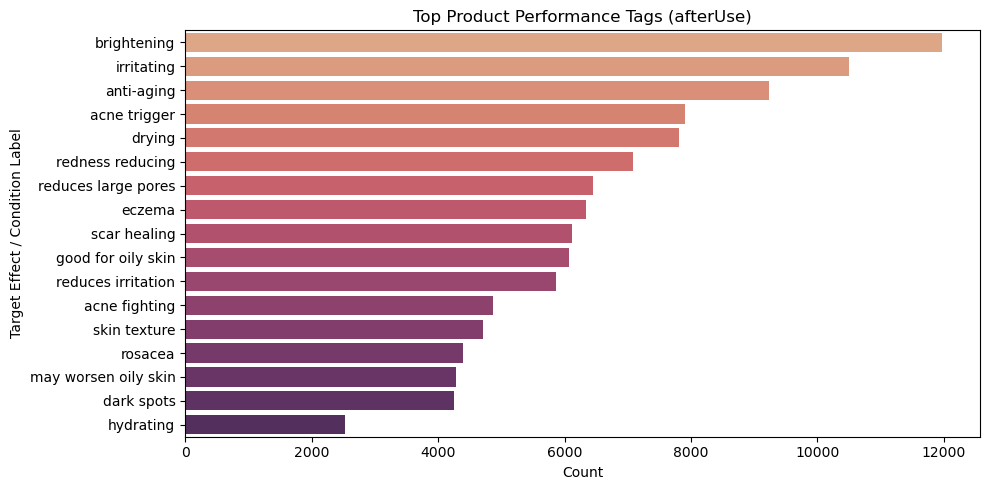

In [21]:
all_tags = []
for val in df['afterUse'].dropna():
    all_tags.extend([t.strip().lower() for t in str(val).split(',') if t.strip()])
    
top_tags = Counter(all_tags).most_common(17)
top_tags_df = pd.DataFrame(top_tags, columns=['Tag / Effect Trigger', 'Frequency'])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_tags_df, x='Frequency', y='Tag / Effect Trigger', hue='Tag / Effect Trigger', palette="flare", legend=False)
plt.title("Top Product Performance Tags (afterUse)")
plt.xlabel("Count")
plt.ylabel("Target Effect / Condition Label")
plt.tight_layout()
plt.show()
